<a href="https://colab.research.google.com/github/philimonkaminga/Text-Classification-with-Neural-Netowks/blob/dev/feedForward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
import tensorflow_hub as hub

In [4]:
df = pd.read_csv('Data/diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


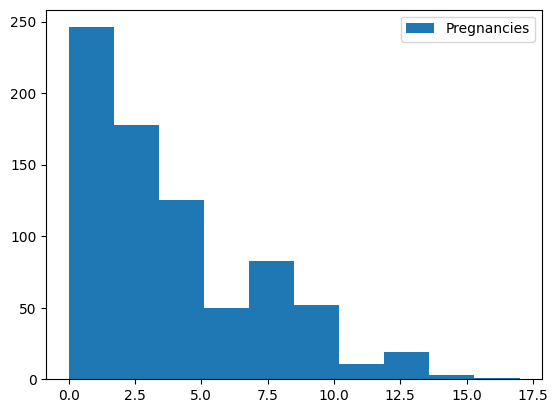

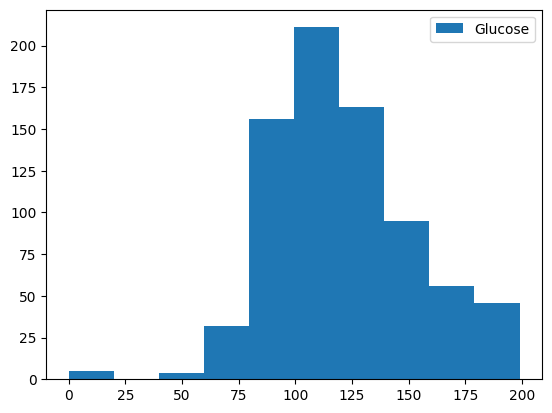

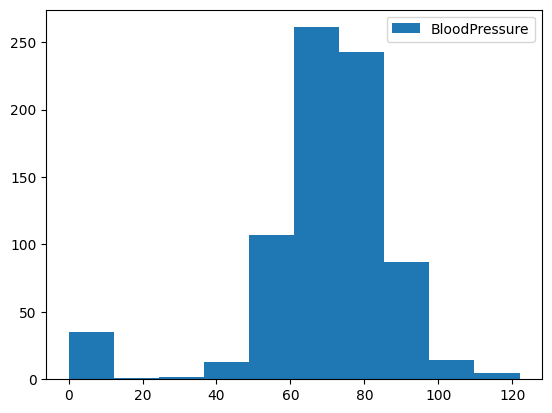

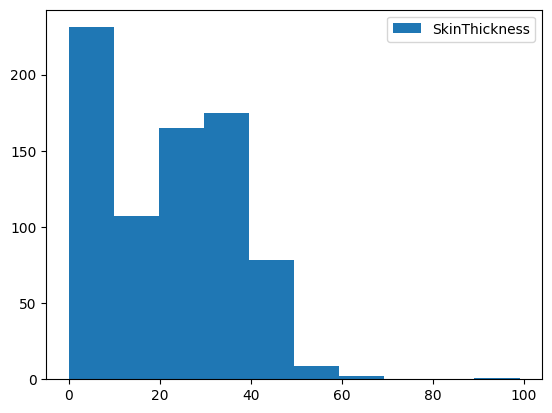

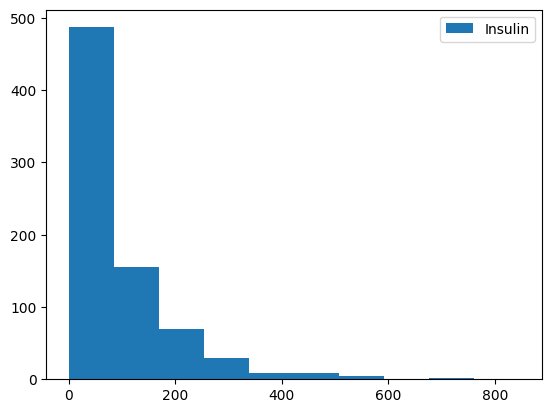

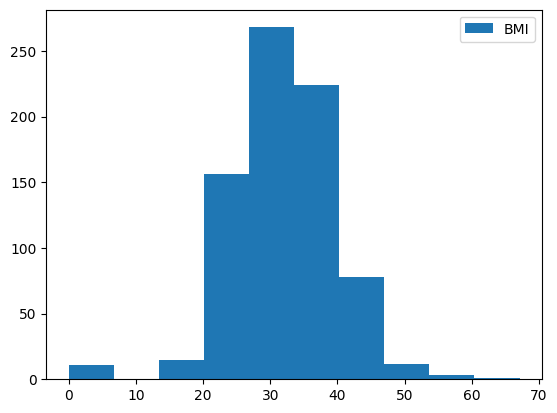

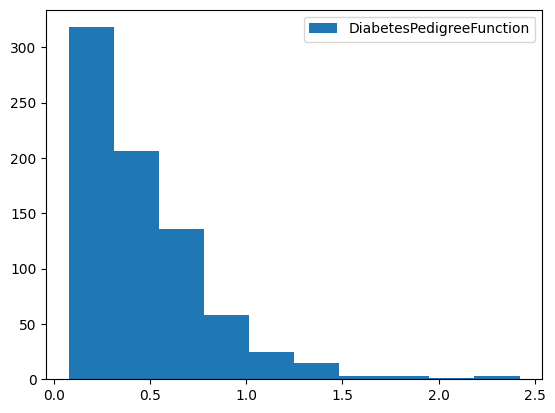

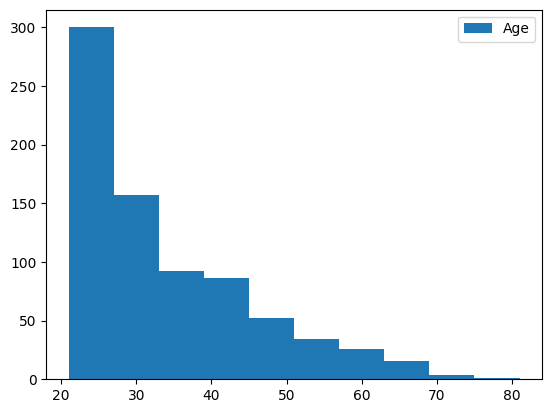

In [6]:
for i in range(len(df.columns[:-1])):
  lable = df.columns[i]
  plt.hist(df[lable], label=lable)
  plt.legend()
  plt.show()

In [7]:
df[df["Outcome"]==0]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
1,1,85,66,29,0,26.6,0.351,31,0
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
10,4,110,92,0,0,37.6,0.191,30,0
...,...,...,...,...,...,...,...,...,...
762,9,89,62,0,0,22.5,0.142,33,0
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0


In [8]:
df[df["Outcome"]==1]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
...,...,...,...,...,...,...,...,...,...
755,1,128,88,39,110,36.5,1.057,37,1
757,0,123,72,0,0,36.3,0.258,52,1
759,6,190,92,0,0,35.5,0.278,66,1
761,9,170,74,31,0,44.0,0.403,43,1


In [11]:
len(df[df['Outcome']==1]), len(df[df['Outcome']==0])

(268, 500)

#### Splitting the dataset into diabetis negative and positive


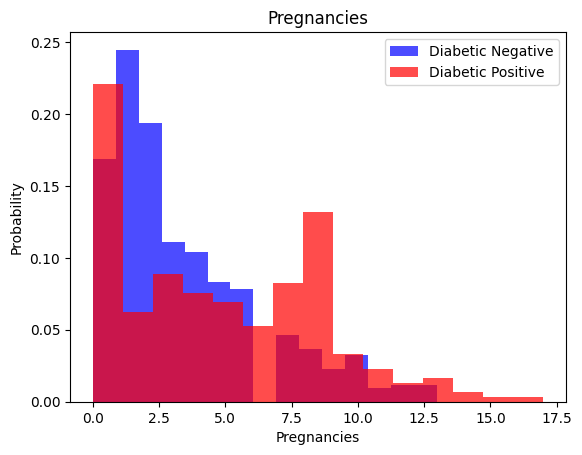

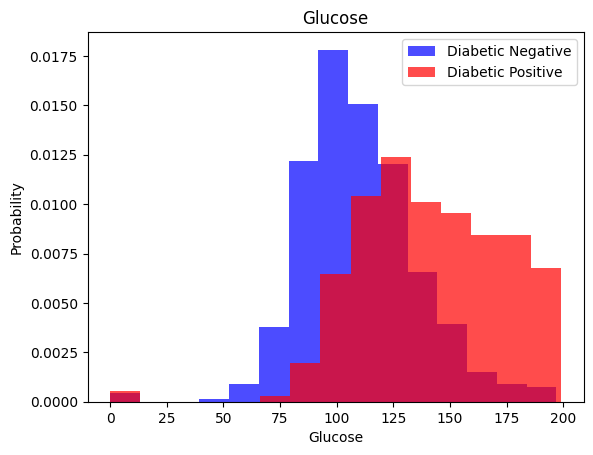

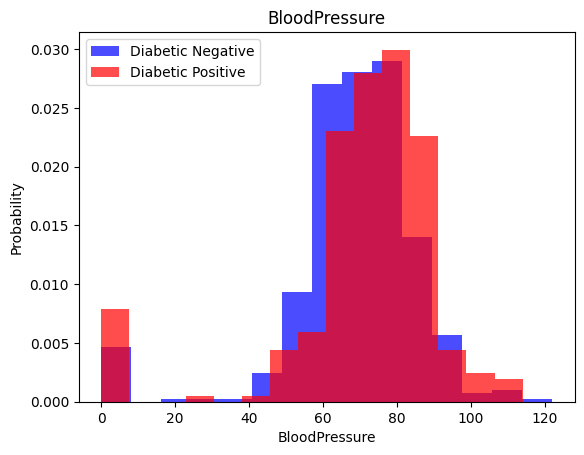

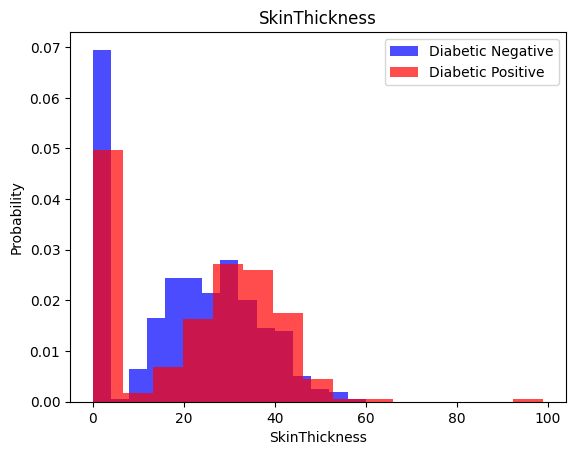

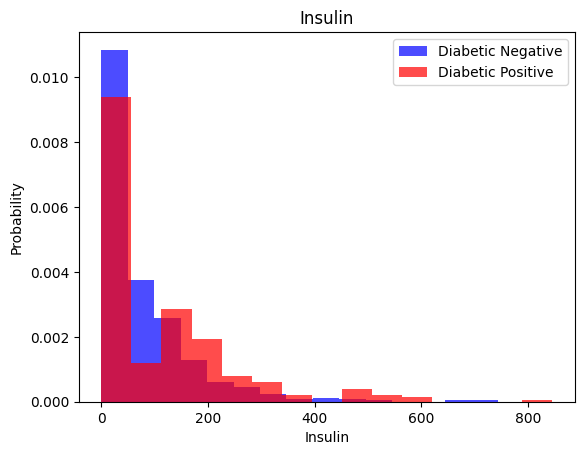

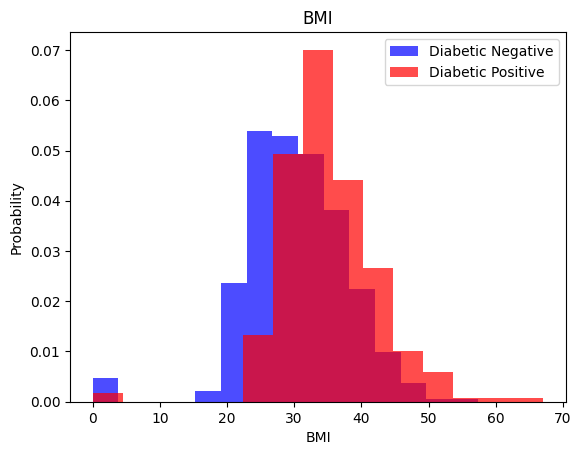

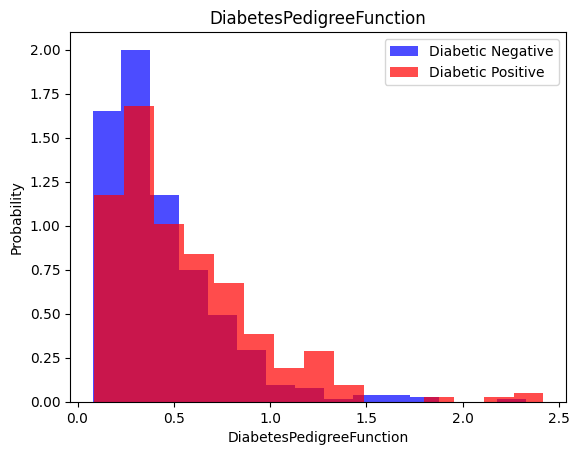

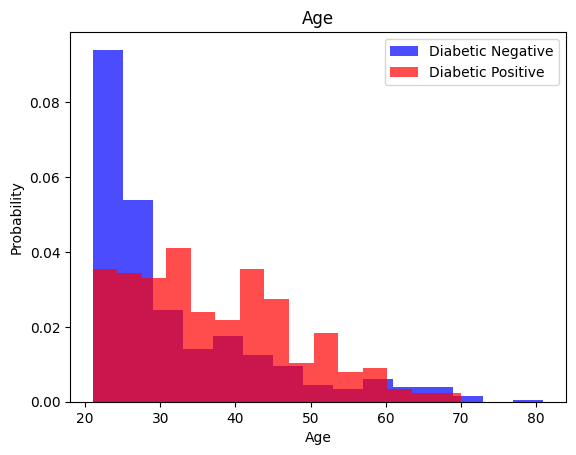

In [13]:
for i in range(len(df.columns[:-1])):
  lable = df.columns[i]
  plt.hist(df[lable][df["Outcome"]==0], label="Diabetic Negative", color="blue", alpha = 0.7, density=True, bins=15)
  plt.hist(df[lable][df["Outcome"]==1], label="Diabetic Positive", color= "red", alpha = 0.7, density=True, bins=15)
  plt.title(lable)
  plt.xlabel(lable)
  plt.ylabel("Probability")
  plt.legend()
  plt.show()

In [18]:
X = df[df.columns[:-1]].values
y = df[df.columns[-1]].values

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=0)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0)

In [28]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")

]

)

In [29]:
model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate = 0.001),
              loss =tf.keras.losses.BinaryCrossentropy(),
              metrics = ["accuracy"])

In [30]:
model.evaluate(X_train, y_train)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3694 - loss: 33.5937


[34.05856704711914, 0.3586956560611725]

In [31]:
model.evaluate(X_valid, y_valid)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3165 - loss: 33.0458 


[31.68191909790039, 0.350649356842041]

In [1]:
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_valid, y_valid))

NameError: name 'model' is not defined